# BrushCue Example: Auto Contrast

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/auto_contrast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/auto-contrast

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


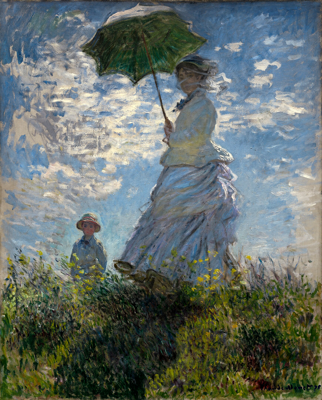

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
hist = input_image.to_ok_lab_hist()
lo = hist.lightness_percentile(0.005)
hi = hist.lightness_percentile(0.995)
inv_range = 1.0 / bc.Float.max((hi - lo), 0.0001)
graph = input_image.color_transformer_shader(
    "let t = clamp((input.r - lo) * inv_range, 0.0, 1.0);\nreturn vec4<f32>(t, input.g, input.b, input.a);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("lo", lo).add("inv_range", inv_range),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
